# Neural Network Training Recipe

This notebook produces figures for the training recipe assessment.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
from satrain.plotting import set_style
set_style()

## Data Augmentation

NameError: name 'x_no_aug' is not defined

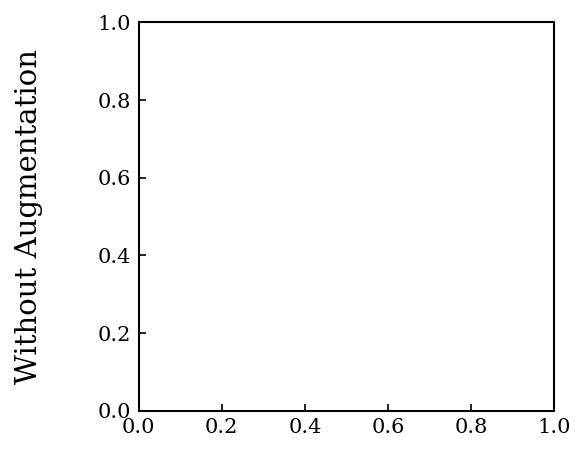

In [3]:
from satrain.plotting import cmap_tbs, cmap_precip
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(17, 8))
gs = GridSpec(3, 5, height_ratios=[1.0, 1.0, 0.1], width_ratios=[0.1] + [1.0] * 4)
norm_precip = LogNorm(1e-1, 1e2)

#
# Non-Augmented
#

ax = fig.add_subplot(gs[0, 0])
ax.set_axis_off()
ax.text(0, 0, s="Without Augmentation", rotation=90, ha="center", va="center", fontsize=14)
ax.set_ylim(-2, 2)

ax = fig.add_subplot(gs[0, 1])
m_in = ax.imshow(x_no_aug["obs_gmi"][gmi_channel], cmap=cmap_tbs)
ax.set_title("GMI, 89 Ghz, V-pol.", loc="center")

ax = fig.add_subplot(gs[0, 2])
ax.imshow(x_no_aug["obs_geo"][geo_channel], norm=m_in.norm, cmap=cmap_tbs)
ax.set_title("ABI, 0.64 $\mu$m", loc="center")

ax = fig.add_subplot(gs[0, 3])
ax.imshow(x_no_aug["obs_geo_ir"][0], norm=m_in.norm, cmap=cmap_tbs)
ax.set_title("Geo IR, 11 $\mu$m", loc="center")

ax = fig.add_subplot(gs[0, 4])
m_t = ax.imshow(np.maximum(y_no_aug["surface_precip"], 1e-3), norm=norm_precip, cmap=cmap_precip)

#
# Augmented
#

ax = fig.add_subplot(gs[1, 0])
ax.set_axis_off()
ax.text(0, 0, s="With Augmentation", rotation=90, ha="center", va="center", fontsize=14)
ax.set_ylim(-2, 2)

ax = fig.add_subplot(gs[1, 1])
ax.imshow(x_aug["obs_gmi"][gmi_channel], norm=m_in.norm, cmap=cmap_tbs)

ax = fig.add_subplot(gs[1, 2])
ax.imshow(x_aug["obs_geo"][geo_channel], norm=m_in.norm, cmap=cmap_tbs)

ax = fig.add_subplot(gs[1, 3])
ax.imshow(x_aug["obs_geo_ir"][0], norm=m_in.norm, cmap=cmap_tbs)

ax = fig.add_subplot(gs[1, 4])
ax.imshow(np.maximum(y_aug["surface_precip"], 1e-3), norm=m_t.norm, cmap=cmap_precip)

cax_in = fig.add_subplot(gs[2, 1:4])
plt.colorbar(m_in, cax=cax_in, orientation="horizontal", label="Normalized Observations")

cax_out = fig.add_subplot(gs[2, 4:])
plt.colorbar(m_t, cax=cax_out, orientation="horizontal", label="Surface Precipitation [mm h$^{-1}$]")

## Learning Rate Search

In [4]:
stats_sgd = xr.load_dataset("/home/simon/src/satrain_models/models/basic_unet/netcdf_metrics/sgd_lr_search_v00.nc")
stats_adamw = xr.load_dataset("/home/simon/src/satrain_models/models/basic_unet/netcdf_metrics/adamw_lr_search_v00.nc")

FileNotFoundError: [Errno 2] No such file or directory: '/home/simon/src/satrain_models/models/basic_unet/netcdf_metrics/sgd_lr_search_v00.nc'

NameError: name 'stats_adamw' is not defined

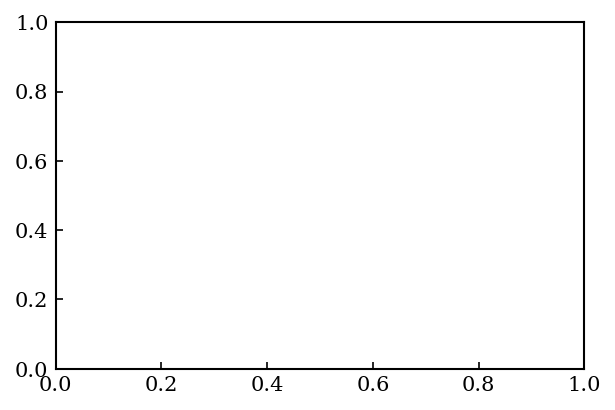

In [6]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 3))
gs = GridSpec(1, 2)

e_adamw = 33
e_sgd = 60

ax = fig.add_subplot(gs[0, 0])
epoch = stats_adamw.step / stats_adamw.step.max() * 100
lr_adamw = stats_adamw.lr.data
mask = np.isfinite(lr_adamw)
ax.plot(epoch[mask], lr_adamw[mask])
lr0 = np.interp(e_adamw, epoch[mask], lr_adamw[mask])
ax.plot([e_adamw, e_adamw], [0, lr0], c="C0", ls=":")
ax.plot([0, e_adamw], [lr0, lr0], c="C0", ls=":")
print('Optimal LR (AdamW):', lr0)

epoch = stats_sgd.step / stats_adamw.step.max() * 100
lr_sgd = stats_sgd.lr.data
mask = np.isfinite(lr_sgd)
ax.plot(epoch[mask], lr_sgd[mask])
lr0 = np.interp(e_sgd, epoch[mask], lr_sgd[mask])
ax.plot([e_sgd, e_sgd], [0, lr0], c="C1", ls=":")
ax.plot([0, e_sgd], [lr0, lr0], c="C1", ls=":")
print('Optimal LR (SGD):', lr0)

plt.yscale("log")
ax.set_title("(a) Learning Rate", loc="left")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_xlim(0, 100)

ax = fig.add_subplot(gs[0, 1])
train_loss_adamw = stats_adamw.train_loss_epoch.data
mask = np.isfinite(train_loss_adamw)
ax.plot(train_loss_adamw[mask])
train_loss_sgd = stats_sgd.train_loss_epoch.data
mask = np.isfinite(train_loss_sgd)
ax.plot(train_loss_sgd[mask])
plt.ylim(0.4, 1)
ax.set_title("(b) Training Loss", loc="left")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_xlim(0, 100)
ax.axvline(x=e_adamw, ls=":", c="C0")
ax.axvline(x=e_sgd, ls=":", c="C1")


## Optimizer and Scheduler

In [11]:
from pathlib import Path
result_path = Path("/home/simon/src/satrain_models/models/basic_unet/netcdf_metrics/")
stats_sgd = xr.load_dataset(result_path / "unet_gmi_gmi_gridded_xl_sgd_v01.nc")
stats_adamw = xr.load_dataset(result_path / "unet_gmi_gmi_gridded_xl_adamw_v01.nc")
stats_sgd_plateau = xr.load_dataset(result_path / "sgd_reduce_on_plateau_v00.nc")
stats_adamw_plateau = xr.load_dataset(result_path / "adamw_reduce_on_plateau_v00.nc")
stats_sgd_ca = xr.load_dataset(result_path / "sgd_warmup_cosine_annealing_v00.nc")
stats_adamw_ca = xr.load_dataset(result_path / "adamw_warmup_cosine_annealing_v00.nc")
stats_sgd_ca_wr = xr.load_dataset(result_path / "sgd_warmup_cosine_annealing_restarts_v00.nc")
stats_adamw_ca_wr = xr.load_dataset(result_path / "adamw_warmup_cosine_annealing_restarts_v00.nc")

In [6]:
results = {
    "SGD, No Schedule": stats_sgd,
    "AdamW, No Schedule": stats_adamw,
    "SGD, Reduce on Plateau": stats_sgd_plateau,
    "AdamW, Reduce on Plateau": stats_adamw_plateau,
    "SGD, Warmup + Cosine Annealing": stats_sgd_ca,
    "Adamw, Warmup + Cosine Annealing": stats_adamw_ca,
    "SGD, Warmup + Cosine Annealing + Warm Restarts": stats_sgd_ca_wr,
    "Adamw, Warmup + Cosine Annealing + Warm Restarts": stats_adamw_ca_wr,
}
    
colors = {
    "SGD, No Schedule": "C0",
    "AdamW, No Schedule": "C0",
    "SGD, Reduce on Plateau": "C1",
    "AdamW, Reduce on Plateau": "C1",
    "SGD, Warmup + Cosine Annealing": "C2",
    "Adamw, Warmup + Cosine Annealing": "C2",
    "SGD, Warmup + Cosine Annealing + Warm Restarts": "C3",
    "Adamw, Warmup + Cosine Annealing + Warm Restarts": "C3",
}

linestyles = {
    "SGD, No Schedule": "-",
    "AdamW, No Schedule": "--",
    "SGD, Reduce on Plateau": "-",
    "AdamW, Reduce on Plateau": "--",
    "SGD, Warmup + Cosine Annealing": "-",
    "Adamw, Warmup + Cosine Annealing": "--",
    "SGD, Warmup + Cosine Annealing + Warm Restarts": "-",
    "Adamw, Warmup + Cosine Annealing + Warm Restarts": "--",
}

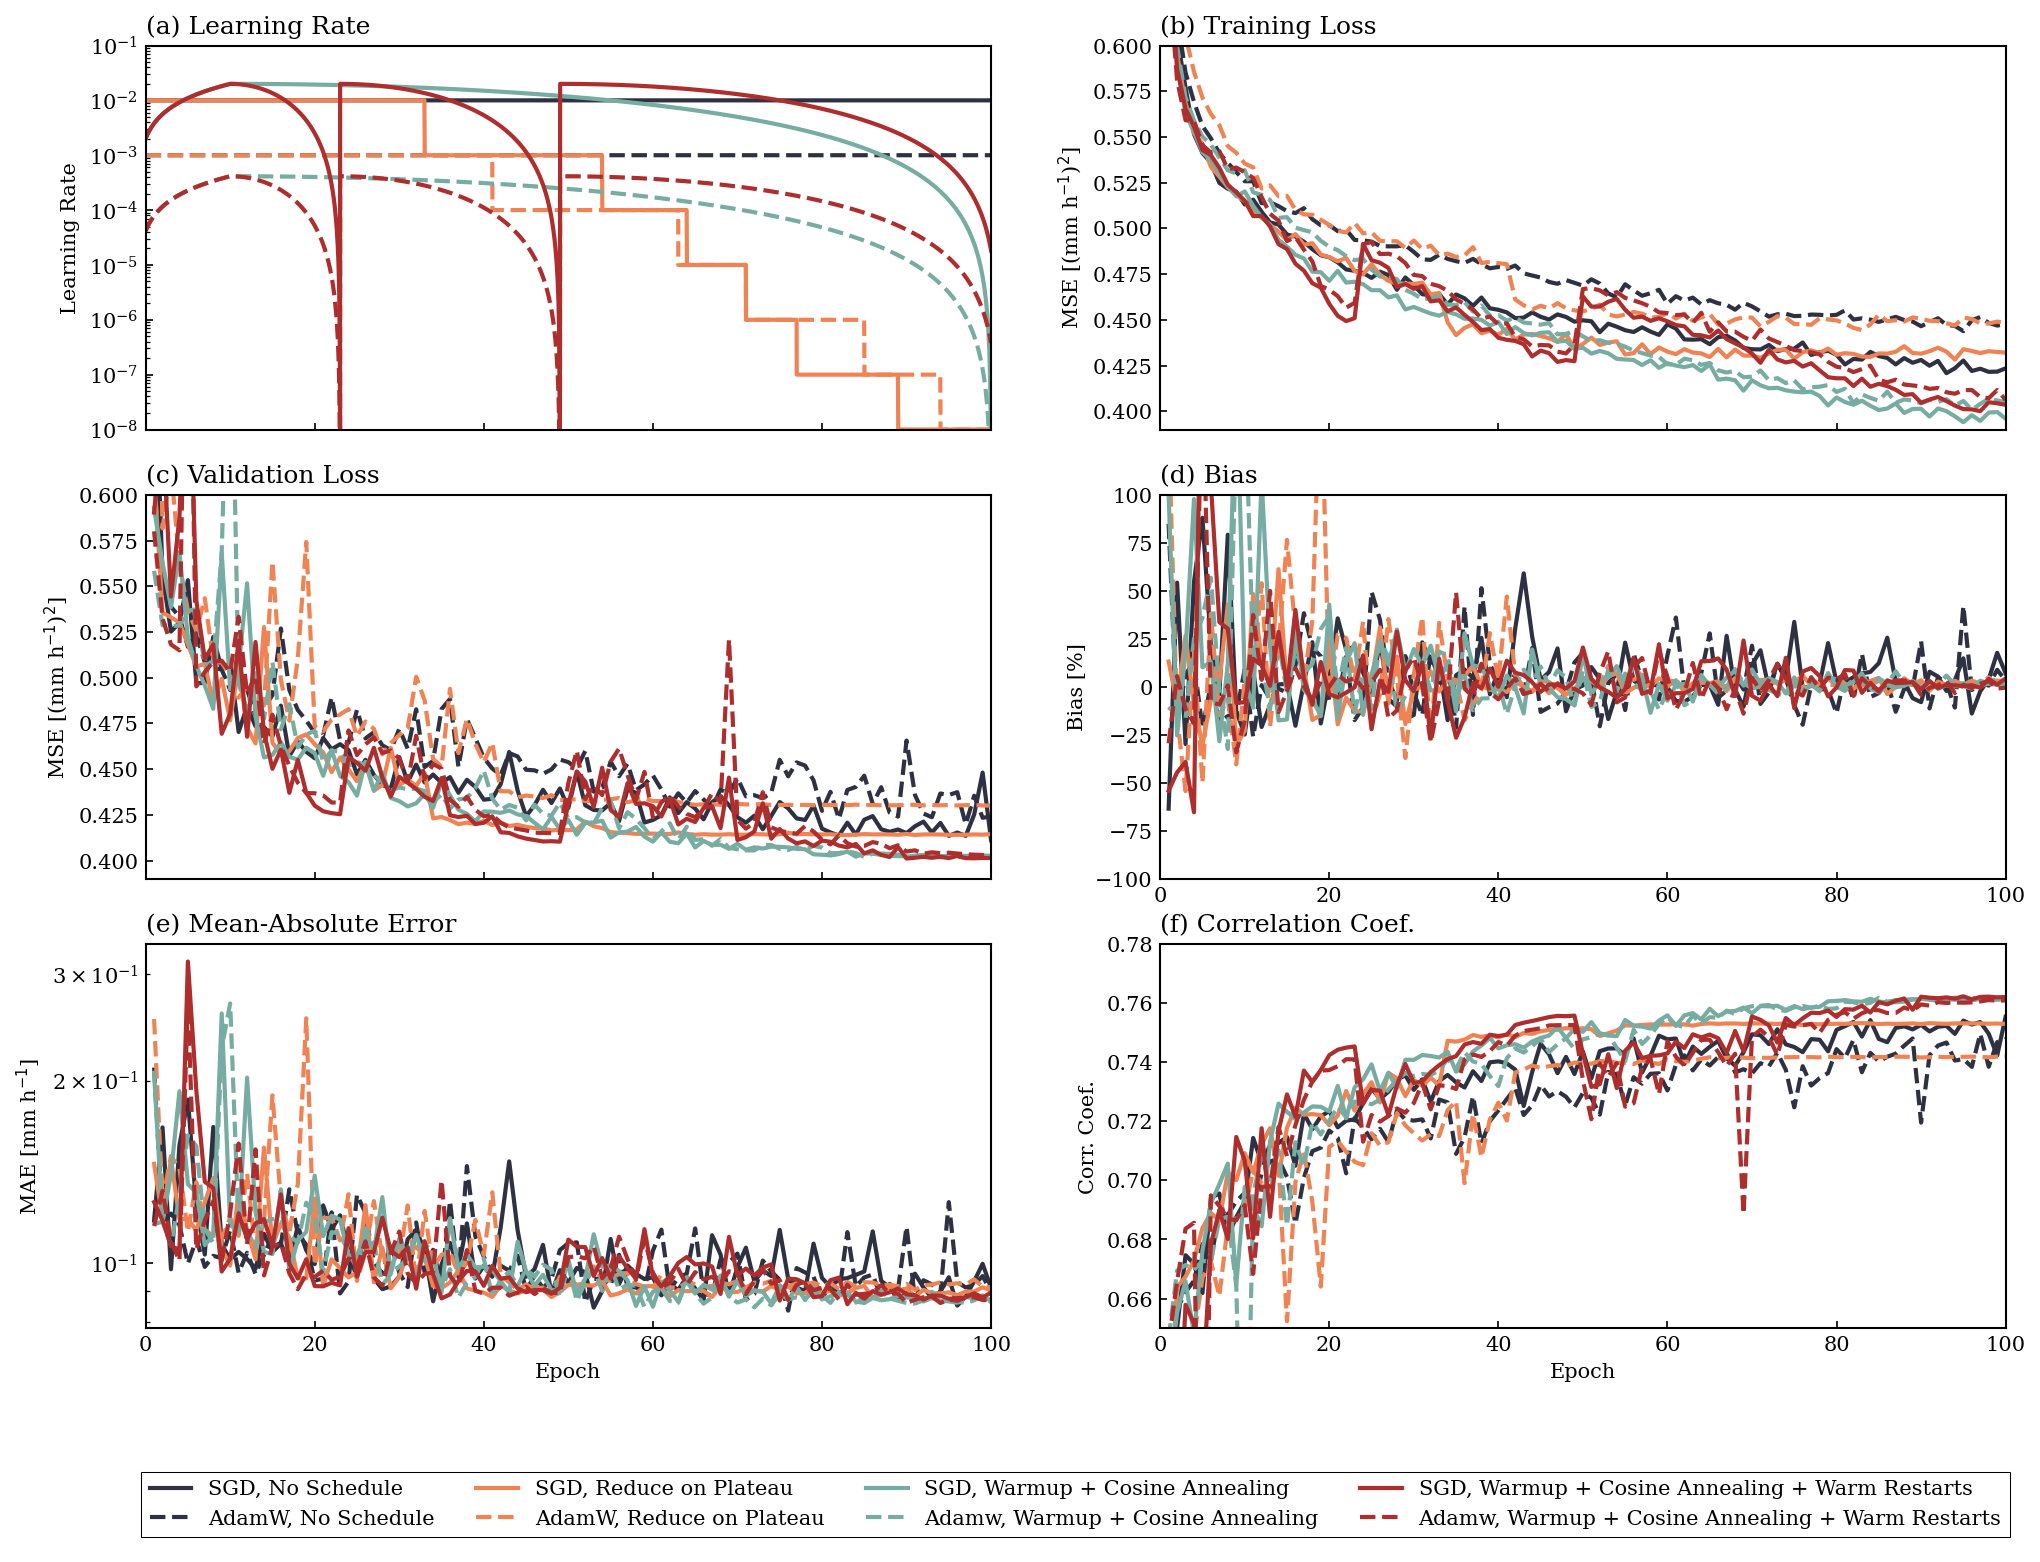

In [7]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 13))
gs = GridSpec(4, 2, height_ratios=[1.0, 1.0, 1.0, 0.4])

e_adamw = 37
e_sgd = 80

lw = 2.0
ax = fig.add_subplot(gs[0, 0])
for name, stats in results.items():
    epoch = stats.step / stats.step.max() * 100
    lr = stats.lr.data
    mask = np.isfinite(lr)
    ax.plot(epoch[mask], lr[mask], c=colors[name], ls=linestyles[name], lw=lw)
ax.set_yscale("log")
ax.set_ylim(1e-8, 1e-1)
ax.set_ylabel("Learning Rate")
ax.set_title("(a) Learning Rate")
ax.set_xticklabels([])
ax.set_xlim(0, 100)

# Training Loss
ax = fig.add_subplot(gs[0, 1])
for name, stats in results.items():
    epoch = stats.step / stats.step.max() * 100
    loss = stats.train_loss_epoch.data
    mask = np.isfinite(loss)
    ax.plot(epoch[mask], loss[mask], c=colors[name], ls=linestyles[name], lw=lw)
    
ax.set_ylim(0.39, 0.6)
ax.set_ylabel("MSE [(mm h$^{-1}$)$^2$]")
ax.set_title("(b) Training Loss")
ax.set_xticklabels([])
ax.set_xlim(0, 100)

# Validation Loss
ax = fig.add_subplot(gs[1, 0])
for name, stats in results.items():
    epoch = stats.step / stats.step.max() * 100
    loss = stats.val_loss.data
    mask = np.isfinite(loss)
    ax.plot(epoch[mask], loss[mask], c=colors[name], ls=linestyles[name], lw=lw)

ax.set_ylim(0.39, 0.6)
ax.set_ylabel("MSE [(mm h$^{-1}$)$^2$]")
ax.set_title("(c) Validation Loss")
ax.set_xticklabels([])
ax.set_xlim(0, 100)

# Bias Loss
ax = fig.add_subplot(gs[1, 1])
for name, stats in results.items():
    epoch = stats.step / stats.step.max() * 100
    bias = stats.val_bias.data
    mask = np.isfinite(bias)
    ax.plot(epoch[mask], bias[mask], c=colors[name], ls=linestyles[name], lw=lw)

ax.set_ylim(-100, 100)
ax.set_ylabel("Bias [%]")
ax.set_title("(d) Bias")
ax.set_xlim(0, 100)

# MAE
ax = fig.add_subplot(gs[2, 0])
for name, stats in results.items():
    epoch = stats.step / stats.step.max() * 100
    mae = stats.val_mae.data
    mask = np.isfinite(mae)
    ax.plot(epoch[mask], mae[mask], c=colors[name], ls=linestyles[name], lw=lw)

#ax.set_ylim(0.0, 0.3)
ax.set_ylabel("MAE [mm h$^{-1}$]")
ax.set_xlabel("Epoch")
ax.set_title("(e) Mean-Absolute Error")
ax.set_yscale("log")
ax.set_xlim(0, 100)

# Corr. coef.
ax = fig.add_subplot(gs[2, 1])
handles = []
for name, stats in results.items():
    epoch = stats.step / stats.step.max() * 100
    corr = stats.val_corrcoef.data
    mask = np.isfinite(corr)
    handles += ax.plot(epoch[mask], corr[mask], c=colors[name], ls=linestyles[name], lw=lw, label=name)

ax.set_ylim(0.65, 0.78)
ax.set_ylabel("Corr. Coef.")
ax.set_title("(f) Correlation Coef.")
ax.set_xlabel("Epoch")
ax.set_xlim(0, 100)

ax = fig.add_subplot(gs[-1, :])
ax.set_axis_off()
ax.legend(handles=handles, ncol=4, loc="lower center")